In [1]:
import sys
import math
import os
import csv
from collections import defaultdict

import numpy as np
import sklearn.metrics
import matplotlib.pyplot as plt
import matplotlib.colors
import plotly.graph_objects as go
from plotly.offline import iplot

In [2]:
DATA_FILE    = '/global/homes/j/jessiem/track_matching_reco_GNN/mcfiles/output/test_ndlar.h5'

In [3]:
from spine.io.core.read.hdf5 import HDF5Reader
from spine.utils.globals import GROUP_COL, COORD_COLS
from spine.utils.gnn.cluster import get_cluster_label
from spine.math.distance import closest_pair
from spine.vis.cluster import scatter_clusters
from spine.vis.point import scatter_points
from spine.vis.layout import HIGH_CONTRAST_COLORS, layout3d
from spine.vis.network import network_topology

Welcome to JupyROOT 6.26/16


In [4]:
# ---------------------------------------------------------------------------
# Cluster / edge classification
# ---------------------------------------------------------------------------

def cluster_class(data_array, cluster_idx):
    """Classify a cluster as 'NDLAr', 'TMS', or 'other' by its voxel z values."""
    z = data_array[cluster_idx][:, COORD_COLS[2]]
    in_ndlar = ((z >= Z_NDLAR_MIN) & (z <= Z_NDLAR_MAX)).sum()
    in_tms   = ((z >= Z_TMS_MIN)   & (z <= Z_TMS_MAX)).sum()
    if in_ndlar == 0 and in_tms == 0:
        return 'other'
    return 'NDLAr' if in_ndlar >= in_tms else 'TMS'


def edge_volume(ci, cj):
    if ci == 'NDLAr' and cj == 'NDLAr': return 'NDLAr-NDLAr'
    if ci == 'TMS'   and cj == 'TMS':   return 'TMS-TMS'
    if {ci, cj} == {'NDLAr', 'TMS'}:   return 'NDLAr-TMS'
    return 'other'


## Confusion Matrix

In [5]:
reader = HDF5Reader(DATA_FILE)

# ---------------------------------------------------------------------------
# Identify true & predicted track matches for all entries
# ---------------------------------------------------------------------------

number_clusters = []
label_mask      = []
pred_mask       = []
num_extra       = []
num_missing     = []
num_wrong       = []

for entry in range(reader.num_entries):
    data      = reader[entry]
    group_ids = get_cluster_label(data['data'], data['clusts'], column=GROUP_COL)
    number_clusters.append(len(group_ids))

    true_mask = group_ids[data['edge_index'][:, 0]] == group_ids[data['edge_index'][:, 1]]
    gnn_mask  = data['edge_pred'][:, 1] > data['edge_pred'][:, 0]
    label_mask.append(true_mask)
    pred_mask.append(gnn_mask)

    true_edge = data['edge_index'][true_mask]
    pred_edge = data['edge_index'][gnn_mask]

    set_true  = set(map(tuple, true_edge))
    set_pred  = set(map(tuple, pred_edge))
    true_only = set_true - set_pred
    pred_only = set_pred - set_true
    not_common = set_true ^ set_pred

    if true_only:  num_missing.append(entry)
    if pred_only:  num_extra.append(entry)
    if not_common: num_wrong.append(entry)

label_array      = np.concatenate(label_mask).ravel()
flattened_label  = label_array.tolist()
prediction_array = np.concatenate(pred_mask).ravel()
flattened_pred   = prediction_array.tolist()

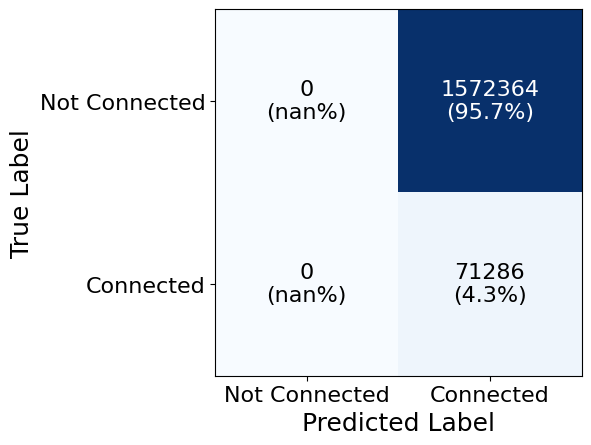

In [6]:
import sklearn
import matplotlib.pyplot as plt

con_mat = sklearn.metrics.confusion_matrix(flattened_label,flattened_pred)
#con_mat = sklearn.metrics.confusion_matrix(flattened_pred,flattened_label)
fig, ax = plt.subplots(figsize=(6, 6))
disp = sklearn.metrics.ConfusionMatrixDisplay(con_mat,display_labels=["Not Connected", "Connected"])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
for text in ax.texts:  # Remove the default text annotations
    text.set_visible(False)

# Annotate the confusion matrix with both count and percentage
sums = np.sum(con_mat, axis=0)
for i in range(con_mat.shape[0]):
    for j in range(con_mat.shape[1]):
        count = con_mat[i, j]
        total = sums[j]
        percentage = 100 * count / total
        if count > (sums[0] + sums[1])*0.7: #Change color of text if background too dark
            textcolor = 'white'
        else:
            textcolor = 'black'
        ax.text(j, i, f'{count}\n({percentage:.1f}%)',
                ha='center', va='center', fontsize=16, color=textcolor)

# Increase font size of tick labels
plt.xticks(fontsize=16)  # Increase x-axis tick label size
plt.yticks(fontsize=16)  # Increase y-axis tick label size

# Increase font size of axis labels
ax.set_xlabel('Predicted Label', fontsize=18)  # Increase x-axis label size
ax.set_ylabel('True Label', fontsize=18)       # Increase y-axis label size
#ax.set_ylabel('Predicted Label', fontsize=18)  # Increase x-axis label size
#ax.set_xlabel('True Label', fontsize=18)       # Increase y-axis label size
plt.tight_layout()
plt.savefig("plots/confusion_matrix.png",dpi=100,bbox_inches="tight",transparent=True)

## Plot spill

In [14]:
# ---------------------------------------------------------------------------
# Global bounding box — must match make_larcv_box() in create_LArCV_TMS_NDLAr.py
# All values in mm (TMS native coordinate frame).
# ---------------------------------------------------------------------------
XMIN_MM, XMAX_MM = -4000.0,  1000.0
YMIN_MM, YMAX_MM = -3705.0,  1000.0
ZMIN_MM, ZMAX_MM =  4000.0, 19000.0

XNUM = int(math.ceil(abs(XMAX_MM - XMIN_MM) / 3))  # 2667 voxels
YNUM = int(math.ceil(abs(YMAX_MM - YMIN_MM) / 3))  # 1567 voxels
ZNUM = int(math.ceil(abs(ZMAX_MM - ZMIN_MM) / 3))  # 5000 voxels

# Detector active volumes in mm
# From TMS_Constants.h and LAr scan (MiniProd5p1_Dev_TMS_NDLAr_track_matching.ipynb)
NDLAR_X = (-3478.48,  3478.48)
NDLAR_Y = (-2166.71,   829.282)
NDLAR_Z = ( 4179.24,  9135.88)

TMS_X   = (-3730.0,   3730.0)
TMS_Y   = (-3702.23,   997.77)
TMS_Z   = (11177.5,  18502.5)

# ---------------------------------------------------------------------------
# Coordinate helpers
# ---------------------------------------------------------------------------

def mm_to_voxel(val_mm, vmin, vmax, vnum):
    """Convert a physical mm position to a voxel index."""
    return (val_mm - vmin) / (vmax - vmin) * (vnum - 1)


def find_num_index(value, min_val, max_val, num):
    if value < min_val or value > max_val:
        raise ValueError(f"Value {value} out of [{min_val}, {max_val}]")
    return int(((value - min_val) / (max_val - min_val)) * (num - 1))


def find_num_indices(values, min_val, max_val, num):
    if any(v < min_val or v > max_val for v in values):
        raise ValueError("Some values out of bounds")
    return [int(((v - min_val) / (max_val - min_val)) * (num - 1)) for v in values]


# Voxel-space z boundaries for the two detectors
Z_NDLAR_MIN = mm_to_voxel(NDLAR_Z[0], ZMIN_MM, ZMAX_MM, ZNUM)
Z_NDLAR_MAX = mm_to_voxel(NDLAR_Z[1], ZMIN_MM, ZMAX_MM, ZNUM)
Z_TMS_MIN   = mm_to_voxel(TMS_Z[0],   ZMIN_MM, ZMAX_MM, ZNUM)
Z_TMS_MAX   = mm_to_voxel(TMS_Z[1],   ZMIN_MM, ZMAX_MM, ZNUM)

print(f"ND-LAr voxel z: [{Z_NDLAR_MIN:.1f}, {Z_NDLAR_MAX:.1f}]")
print(f"TMS    voxel z: [{Z_TMS_MIN:.1f},   {Z_TMS_MAX:.1f}]")

# ---------------------------------------------------------------------------
# Bounding box drawing
# ---------------------------------------------------------------------------

def add_3d_box(fig, x_min, x_max, y_min, y_max, z_min, z_max,
               color='black', name='', showlegend=True):
    """Draw a rectangular box as line traces in a plotly figure (voxel coords)."""
    r = np.array([
        [x_min, y_min, z_min], [x_max, y_min, z_min],
        [x_max, y_max, z_min], [x_min, y_max, z_min],
        [x_min, y_min, z_max], [x_max, y_min, z_max],
        [x_max, y_max, z_max], [x_min, y_max, z_max],
    ])
    edges = [
        [r[0], r[1], r[2], r[3], r[0]],
        [r[4], r[5], r[6], r[7], r[4]],
        [r[0], r[4]], [r[1], r[5]], [r[2], r[6]], [r[3], r[7]],
    ]
    first = True
    for edge in edges:
        x_vals, y_vals, z_vals = zip(*edge)
        fig.add_trace(go.Scatter3d(
            x=x_vals, y=y_vals, z=z_vals,
            mode='lines',
            line=dict(color=color, width=2),
            name=name if first else '',
            showlegend=showlegend and first,
            legendgroup=name,
        ))
        first = False


def draw_NDLAr(fig):
    """Draw ND-LAr active volume bounding box (converted to voxel coordinates)."""
    add_3d_box(
        fig,
        x_min=find_num_index(NDLAR_X[0], XMIN_MM, XMAX_MM, XNUM),
        x_max=find_num_index(NDLAR_X[1], XMIN_MM, XMAX_MM, XNUM),
        y_min=find_num_index(NDLAR_Y[0], YMIN_MM, YMAX_MM, YNUM),
        y_max=find_num_index(NDLAR_Y[1], YMIN_MM, YMAX_MM, YNUM),
        z_min=find_num_index(NDLAR_Z[0], ZMIN_MM, ZMAX_MM, ZNUM),
        z_max=find_num_index(NDLAR_Z[1], ZMIN_MM, ZMAX_MM, ZNUM),
        color='black', name='ND-LAr active volume',
    )


def draw_TMS(fig):
    """Draw TMS active volume bounding box (converted to voxel coordinates)."""
    add_3d_box(
        fig,
        x_min=find_num_index(TMS_X[0], XMIN_MM, XMAX_MM, XNUM),
        x_max=find_num_index(TMS_X[1], XMIN_MM, XMAX_MM, XNUM),
        y_min=find_num_index(TMS_Y[0], YMIN_MM, YMAX_MM, YNUM),
        y_max=find_num_index(TMS_Y[1], YMIN_MM, YMAX_MM, YNUM),
        z_min=find_num_index(TMS_Z[0], ZMIN_MM, ZMAX_MM, ZNUM),
        z_max=find_num_index(TMS_Z[1], ZMIN_MM, ZMAX_MM, ZNUM),
        color='blue', name='TMS active volume',
    )


ND-LAr voxel z: [59.7, 1711.6]
TMS    voxel z: [2392.0,   4833.2]


In [11]:
def plot_3D_viewer(entry):
    print(f"Entry {entry}")
    data = reader[entry]
    fig = go.Figure()
    #fig = setup_figure(fig, entry)

    CB_color_cycle = ['#332288', '#117733', '#44AA99', '#88CCEE',
                      '#EA4040', '#0B57CB', '#D79ABB', '#7D7A7A', '#D0B58F']

    mask       = data['edge_pred'][:, 1] > data['edge_pred'][:, 0]
    edge_index = data['edge_index'][mask]
    print("Predicted connections:", edge_index)

    group_ids = get_cluster_label(data['data'], data['clusts'], column=GROUP_COL)
    true_mask = group_ids[data['edge_index'][:, 0]] == group_ids[data['edge_index'][:, 1]]
    real       = data['edge_index'][true_mask]
    print("True connections:", real)

    trace = []
    trace += network_topology_here(
        data['data'], data['clusts'], edge_index,
        clust_labels=group_ids,
        edge_labels=None,
        markersize=2,
        colorscale=CB_color_cycle,
        name='',
        linewidth=0,
        show_edges=None,
    )
    fig = go.Figure(data=trace, layout=layout3d())

    # Axis ticks: voxel indices → mm labels
    original_xticks = np.linspace(0, XNUM, 5)
    new_xticks      = np.linspace(XMIN_MM, XMAX_MM, 5)
    original_yticks = np.linspace(0, YNUM, 8)
    new_yticks      = np.linspace(YMIN_MM, YMAX_MM, 8)
    original_zticks = np.linspace(0, ZNUM, 10)
    new_zticks      = np.linspace(ZMIN_MM, ZMAX_MM, 10)

    fig.update_layout(
        scene=dict(
            xaxis=dict(
                tickvals=original_xticks,
                ticktext=[f"{int(v)}" for v in new_xticks],
                title=dict(text="Horizontal Axis (mm)", font=dict(size=12)),
                tickfont=dict(size=12),
            ),
            yaxis=dict(
                tickvals=original_yticks,
                ticktext=[f"{int(v)}" for v in new_yticks],
                title=dict(text="Vertical Axis (mm)", font=dict(size=12)),
                tickfont=dict(size=12),
            ),
            zaxis=dict(
                tickvals=original_zticks,
                ticktext=[f"{int(v)}" for v in new_zticks],
                title=dict(text="Beam Axis (mm)", font=dict(size=12)),
                tickfont=dict(size=12),
            ),
        ),
        margin=dict(l=200, r=50, b=100, t=0),
        scene_camera=dict(
            eye=dict(x=-2, y=0.2, z=0.087),
            up=dict(x=0, y=1, z=0),
        ),
    )

    draw_NDLAr(fig)
    draw_TMS(fig)

    fig.update_layout(showlegend=True)
    iplot(fig)
    return fig

In [15]:
fig = plot_3D_viewer(0)

Entry 0
Predicted connections: [[  0   1]
 [  1   0]
 [  0   2]
 ...
 [560 558]
 [559 560]
 [560 559]]
True connections: [[  1  58]
 [ 58   1]
 [  3  72]
 ...
 [556 554]
 [555 556]
 [556 555]]


ValueError: Value 3478.48 out of [-4000.0, 1000.0]

In [8]:
def network_topology_here(
    points,
    clusts,
    edge_index,
    clust_labels=None,
    edge_labels=None,
    mode="scatter",
    color=None,
    line=None,
    linewidth=2,
    show_edges=True,
    clust_indices=None,
    name=None,
    **kwargs,
):
    """Network 3D topological representation in Euclidean space.

    Parameters
    ----------
    points : np.ndarray
        (N, 3) array of N points of (..., x, y, z,...) coordinate information
    clusts : List[np.ndarray]
        (C) List of cluster indexes
    edge_index : np.ndarray
        (E, 2) List of connections between clusters
    clust_labels : np.ndarray, optional
        (C) List of cluster labels
    edge_labels : np.ndarray, optional
        (E) List of edge labels
    mode : str, default 'scatter'
        Drawing mode; one of 'circle', 'scatter', 'ellipsoid', 'cone' or 'hull'
    color : Union[str, np.ndarray], optional
        Color of clusters or (C) list of color of clusters
    line : dict, optional
        Line property dictionary
    linewidth : float, default 2
        Width of the edge lines
    show_edges : bool, default True
        If False, skip drawing edge lines entirely
    clust_indices : array-like of int, optional
        Indices into clusts to plot. If None, all clusters are plotted.
        Edges where either endpoint is not in clust_indices are dropped.
    name : str, optional
        Name of the network
    **kwargs : dict, optional
        List of additional arguments to pass to plotly

    Returns
    -------
    List[Union[plotly.graph_objs.Scatter3d, plotly.graph_objs.Mesh3d]]
        Node and edge traces in the same list
    """
    if points.shape[1] != 3:
        points = points[:, COORD_COLS]

    assert color is None, "Use `clust_labels` instead of `color` to specify node colors."

    # Apply cluster subset filter
    if clust_indices is not None:
        clust_indices = np.asarray(clust_indices)
        clusts = [clusts[i] for i in clust_indices]
        if clust_labels is not None:
            clust_labels = clust_labels[clust_indices]

        # Remap edge indices; drop edges that touch excluded clusters
        old_to_new = {int(old): new for new, old in enumerate(clust_indices)}
        if len(edge_index):
            keep = [i for i, (a, b) in enumerate(edge_index)
                    if int(a) in old_to_new and int(b) in old_to_new]
            if keep:
                edge_index = np.array([[old_to_new[int(a)], old_to_new[int(b)]]
                                       for a, b in edge_index[keep]])
                if edge_labels is not None:
                    edge_labels = edge_labels[np.array(keep)]
            else:
                edge_index = np.empty((0, 2), dtype=int)
                edge_labels = None
        else:
            edge_index = np.empty((0, 2), dtype=int)

    prefix    = f"{name}" if name is not None else "Graph"
    node_name = name if edge_index is None else f"{prefix} nodes"
    edge_name = f"{prefix} edges"

    single_trace = mode in ["circle", "scatter"]
    traces = scatter_clusters(
        points, clusts,
        color=clust_labels,
        single_trace=single_trace,
        name=node_name,
        mode=mode,
        **kwargs,
    )

    if not show_edges:
        return traces

    edge_vertices = np.empty((0, 3), dtype=points.dtype)
    if len(edge_index):
        edge_vertices = []
        if mode in ["circle", "ellipsoid"]:
            cent = [points[c].mean(axis=0) for c in clusts]
            for i, j in edge_index:
                edge_vertices.extend([cent[i], cent[j], [None, None, None]])
        elif mode in ["scatter", "hull"]:
            for i, j in edge_index:
                vi, vj = points[clusts[i]], points[clusts[j]]
                i1, i2, _ = closest_pair(vi, vj, "recursive")
                edge_vertices.extend([vi[i1], vj[i2], [None, None, None]])
        else:
            sts = []
            for trace in traces:
                start = [trace["x"][0], trace["y"][0], trace["z"][0]]
                sts.append(start)
            for i, j in edge_index:
                edge_vertices.extend([sts[i], sts[j], [None, None, None]])
        edge_vertices = np.vstack(edge_vertices)

    if edge_labels is not None:
        edge_labels = np.repeat(edge_labels, 3)

    traces += scatter_points(
        edge_vertices,
        color=edge_labels,
        line=line,
        linewidth=linewidth,
        mode="lines",
        name=edge_name,
    )

    return traces
